In [1]:
print("Python testing")
#Basic test script to ensure Python environment is functional

Python testing


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df_raw = pd.read_csv("../data/telecom_customer_churn.csv")

df = df_raw.copy(deep=True)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)


Dataset Loaded Successfully
Dataset Shape: (7043, 38)


In [4]:
print(df.columns.tolist())


['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason']


# Data Inspection and Quality Assessment
## Dataset Information

In [5]:
df.info()

# We should consider converting some of these data types into numerical types.
# For example, the AI won't understand a thing if Gender is "male" or "female", but "1" or "0" should be okay.
# We should take this case-by-case and be careful converting

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

In [6]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# Some of these variables we should be careful with using as-is.
# For example: Zip code, a higher value doesn't meaningfully convey anything
# We should do something about some of these variables, ensure they don't misguide our AI

# So far my picks for 'special' features are:
# Customer ID, City, Zip code, Latitude, Longitude, Paperless billing (maybe irrelevant?), Payment method (maybe irrelevant?)
# Churn category (too many values missing), Churn Reason (too many values missing)

Rows and Columns:
(7043, 38)

Column Names:
['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason']


In [7]:
missing_values = df.isnull().sum()

print(missing_values)

# Checking the database, 'offer' for example isn't lacking values as 3877 would suggest, should look into this.
# Churn category and churn reason are both absolutely lacking real data points (cross referencing the database file)
# We should consider removing these two features entirely
# Perhaps do so on a deepclone of the database as best practice entails

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [8]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [9]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [10]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n----- {col} -----")
    print(df[col].value_counts(dropna=False))

# Note: "NaN" is because dropna is set to false, Pandas will report missing values as NaN
# This way the data isn't misrepresented if a value is missing

# Data seems okay, no major spelling mistakes or equivalent duplicate values it seems


----- Customer ID -----
Customer ID
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
0013-EXCHZ    1
             ..
9987-LUTYD    1
9992-RRAMN    1
9992-UJOEL    1
9993-LHIEB    1
9995-HOTOH    1
Name: count, Length: 7043, dtype: int64

----- Gender -----
Gender
Male      3555
Female    3488
Name: count, dtype: int64

----- Married -----
Married
No     3641
Yes    3402
Name: count, dtype: int64

----- City -----
City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Johannesburg          2
Eldridge              2
Holtville             2
South Lake Tahoe      2
Jacumba               2
Name: count, Length: 1106, dtype: int64

----- Offer -----
Offer
NaN        3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

----- Phone Service -----
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

----- Multiple Line

C:\Users\Baller\AppData\Local\Temp\ipykernel_25192\4046533156.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [11]:
print("Age <= 0:", (df["Age"] <= 0).sum())
print("Age > 100:", (df["Age"] > 100).sum())

# A check for customers' ages on the assumption that no customer is equal or less than 0 years old, or above 100 years old
# Above 100 years old is odd but doesn't invalidate, but 0 years old does.

Age <= 0: 0
Age > 100: 0


In [12]:
zero_revenue = df[df["Total Revenue"] == 0]
print("Customers with zero total revenue:", len(zero_revenue))

negative_revenue = df[df["Total Revenue"] < 0]
print("Customers with negative total revenue:", len(negative_revenue))

negative_dependents = df[df["Number of Dependents"] < 0]
print("Customers with negative number of dependents:", len(negative_dependents))

negative_referrals = df[df["Number of Referrals"] < 0]
print("Customers with negative number of referrals:", len(negative_referrals))

negative_tenure = df[df["Tenure in Months"] < 0]
print("Customers with negative tenure in months:", len(negative_tenure))

negative_long_distance = df[df["Avg Monthly Long Distance Charges"] < 0]
print("Customers with negative average monthly long distance charges:", len(negative_long_distance))

negative_gb_download = df[df["Avg Monthly GB Download"] < 0]
print("Customers with negative average monthly GB download:", len(negative_gb_download))

negative_monthly_charge = df[df["Monthly Charge"] < 0]
print("Customers with negative monthly charge:", len(negative_monthly_charge))

negative_total_charges = df[df["Total Charges"] < 0]
print("Customers with negative total charges:", len(negative_total_charges))

negative_total_refunds = df[df["Total Refunds"] < 0]
print("Customers with negative total refunds:", len(negative_total_refunds))

negative_extra_data = df[df["Total Extra Data Charges"] < 0]
print("Customers with negative total extra data charges:", len(negative_extra_data))

negative_long_distance_total = df[df["Total Long Distance Charges"] < 0]
print("Customers with negative total long distance charges:", len(negative_long_distance_total))


# This data is far too perfect with over 7,000 records. It definitely leans towards synthetic
# 120 Customers with negative monthly charges

# Assumptions:
# A 'customer' is one who has paid the company for their services, thus we can assume valid values are above $0.00
# Number of dependents should never be lower than 0, logically invalid
# Number of referals cannot be lower than 0
# Customer tenure in months should always be equal or higher than 0 (quitting immediately is reasonable and possible)
# The rest of the $ charges should logically always be equal or above to $0.00

Customers with zero total revenue: 0
Customers with negative total revenue: 0
Customers with negative number of dependents: 0
Customers with negative number of referrals: 0
Customers with negative tenure in months: 0
Customers with negative average monthly long distance charges: 0
Customers with negative average monthly GB download: 0
Customers with negative monthly charge: 120
Customers with negative total charges: 0
Customers with negative total refunds: 0
Customers with negative total extra data charges: 0
Customers with negative total long distance charges: 0


In [13]:
duplicate_ids = df[df["Customer ID"].duplicated(keep=False)]
print("Rows belonging to duplicated Customer IDs:", len(duplicate_ids))

# We checked for identical rows before but this checks for identical customer IDs in the event of a data entry mistake or duplicated and mismatched records.

Rows belonging to duplicated Customer IDs: 0


# Exploratory Data Analysis

In [14]:
[col for col in df.columns if "Churn" in col]

['Churn Category', 'Churn Reason']

In [15]:
import pandas as pd

df = pd.read_csv("../data/telecom_customer_churn.csv")

print("Dataset Loaded")

Dataset Loaded


In [16]:
print(df.columns.tolist())

['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason']


In [17]:
[col for col in df.columns if "Churn" in col]

['Churn Category', 'Churn Reason']

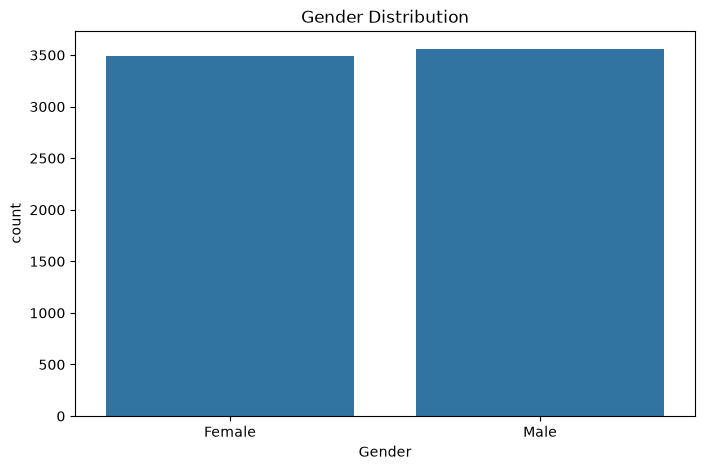

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x="Gender",
    data=df
)

plt.title("Gender Distribution")
plt.show()

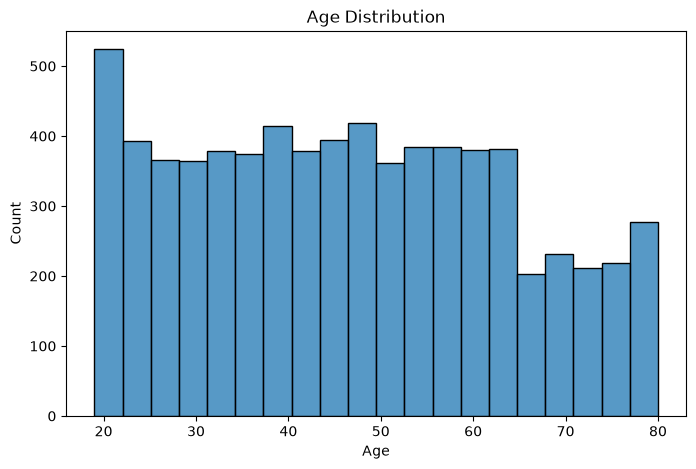

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20
)

plt.title("Age Distribution")
plt.show()

# Exploratory Data Analysis Findings

## Age Distribution
The age distribution appears relatively balanced across customer groups, with a noticeable concentration in younger and middle-aged customers.

## Data Quality Findings
- No duplicate records were found.
- Missing values were identified and assessed.
- Customer ID was removed because it does not contribute to prediction.

## Data Transformation
- Churn Category and Churn Reason were removed to prevent target leakage.
- A cleaned dataset was produced for further modelling.

In [20]:
df = df.drop(columns=["Customer ID"])
df = df.drop(columns=["City"])
df = df.drop(columns=["Zip Code"])
df = df.drop(columns=["Latitude"])
df = df.drop(columns=["Longitude"])
df = df.drop(columns=["Paperless Billing"])
df = df.drop(columns=["Payment Method"])
df = df.drop(columns=["Churn Category"])
df = df.drop(columns=["Churn Reason"])
df.head()

# Removing features deemed irrelevant towards predicting customer churn.
# Removed only from clone

# Huyin: I deemed these variables as irrelevant because I currently do not see how they would be significant towards accurately predicting customer churn.
# Customer ID is randomized, City shouldn't matter, Zip code cannot be helped, latitude and longitude is irrelevant for this investigation, 
# paperless billing is personal choice and shouldn't impact results, so is payment method, churn category and churn reason both OVERWHELMINGLY 
# have missing values resulting in a worthless feature to include.
# Mutal agreement

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Streaming Music,Unlimited Data,Contract,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,Female,37,Yes,0,2,9,NaN,Yes,42.39,No,...,No,Yes,One Year,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,Male,46,No,0,0,9,NaN,Yes,10.69,Yes,...,Yes,No,Month-to-Month,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,Male,50,No,0,0,4,Offer E,Yes,33.65,No,...,No,Yes,Month-to-Month,73.9,280.85,0.00,0,134.60,415.45,Churned
3,Male,78,Yes,0,1,13,Offer D,Yes,27.82,No,...,No,Yes,Month-to-Month,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,Female,75,Yes,0,3,3,NaN,Yes,7.38,No,...,No,Yes,Month-to-Month,83.9,267.40,0.00,0,22.14,289.54,Churned


In [21]:
df_raw.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [22]:
categorical_cols = df.select_dtypes(include="str").columns

for col in categorical_cols:
    print(f"\n----- {col} -----")
    print(df[col].value_counts(dropna=False))


----- Gender -----
Gender
Male      3555
Female    3488
Name: count, dtype: int64

----- Married -----
Married
No     3641
Yes    3402
Name: count, dtype: int64

----- Offer -----
Offer
NaN        3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

----- Phone Service -----
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

----- Multiple Lines -----
Multiple Lines
No     3390
Yes    2971
NaN     682
Name: count, dtype: int64

----- Internet Service -----
Internet Service
Yes    5517
No     1526
Name: count, dtype: int64

----- Internet Type -----
Internet Type
Fiber Optic    3035
DSL            1652
NaN            1526
Cable           830
Name: count, dtype: int64

----- Online Security -----
Online Security
No     3498
Yes    2019
NaN    1526
Name: count, dtype: int64

----- Online Backup -----
Online Backup
No     3088
Yes    2429
NaN    1526
Name: count, dtype: int64

----- Device Protection Plan -----
Devic

In [23]:
df["Gender"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

df["Married"] = df["Married"].map({
    "No": 0,
    "Yes": 1
})

df["Phone Service"] = df["Phone Service"].map({
    "No": 0,
    "Yes": 1
})

df["Multiple Lines"] = df["Multiple Lines"].map({
    "No": 0,
    "Yes": 1
})

df["Internet Service"] = df["Internet Service"].map({
    "No": 0,
    "Yes": 1
})

df["Online Security"] = df["Online Security"].map({
    "No": 0,
    "Yes": 1
})

df["Online Backup"] = df["Online Backup"].map({
    "No": 0,
    "Yes": 1
})

df["Device Protection Plan"] = df["Device Protection Plan"].map({
    "No": 0,
    "Yes": 1
})

df["Premium Tech Support"] = df["Premium Tech Support"].map({
    "No": 0,
    "Yes": 1
})

df["Streaming TV"] = df["Streaming TV"].map({
    "No": 0,
    "Yes": 1
})

df["Streaming Movies"] = df["Streaming Movies"].map({
    "No": 0,
    "Yes": 1
})

df["Streaming Music"] = df["Streaming Music"].map({
    "No": 0,
    "Yes": 1
})

df["Unlimited Data"] = df["Unlimited Data"].map({
    "No": 0,
    "Yes": 1
})


binary_cols = [
    "Gender",
    "Married",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data"
]

for col in binary_cols:
    print(f"\n----- {col} -----")
    print(df[col].value_counts(dropna=False))


# Converting binary choices to numerical so AI can use them.
# These are okay to do, being binary 1 isn't more significant than 0 is, thus the impact of each option hasn't changed.
# Haven't converted everything yet, left out offer, internet type, contract, and customer status (These need special treatment).


----- Gender -----
Gender
1    3555
0    3488
Name: count, dtype: int64

----- Married -----
Married
0    3641
1    3402
Name: count, dtype: int64

----- Phone Service -----
Phone Service
1    6361
0     682
Name: count, dtype: int64

----- Multiple Lines -----
Multiple Lines
0.0    3390
1.0    2971
NaN     682
Name: count, dtype: int64

----- Internet Service -----
Internet Service
1    5517
0    1526
Name: count, dtype: int64

----- Online Security -----
Online Security
0.0    3498
1.0    2019
NaN    1526
Name: count, dtype: int64

----- Online Backup -----
Online Backup
0.0    3088
1.0    2429
NaN    1526
Name: count, dtype: int64

----- Device Protection Plan -----
Device Protection Plan
0.0    3095
1.0    2422
NaN    1526
Name: count, dtype: int64

----- Premium Tech Support -----
Premium Tech Support
0.0    3473
1.0    2044
NaN    1526
Name: count, dtype: int64

----- Streaming TV -----
Streaming TV
0.0    2810
1.0    2707
NaN    1526
Name: count, dtype: int64

----- Streaming M

In [24]:
df["Offer"] = df["Offer"].fillna("None")

df["Offer_Received"] = (df["Offer"] != "None").astype(int)

offer_dummies = pd.get_dummies(
    df["Offer"],
    prefix="Offer",
    dtype=int
)

offer_dummies = offer_dummies.drop(columns=["Offer_None"])

df = pd.concat([df, offer_dummies], axis=1)

df = df.drop(columns=["Offer"])

# Trying to encode the "Offer" feature.
# Here is my line of reasoning, this one is a tad weirder than the others, not as simple.
# To receive "None", to say the customer did NOT receive an offer should be represented mathematically as the LEAST significant
# Since to receive no offers means they did not get a single advantage to their cost.
# However, we must also specify that offer "A" is not nessesarily mathematically more significant than "B" or "C"
# In other words, "None" should be represented mathematically smaller than all the other offer options from A to E, but within those they should be
# on the same level mathematically wise but still differentiated.
# That's what I'm trying to achieve here.

In [25]:
df["Internet Type"] = df["Internet Type"].fillna("Missing")

df = pd.get_dummies(
    df,
    columns=["Internet Type"],
    dtype=int
)

# Here is my reasoning for this.
# We need to treat each present value as different but without a ranking, logically we cannot assume one is more significant than the other.
# However! Certain customers with "Internet Service" = "No" will naturally cause a missing value in "Internet Type".
# That's what "NaN" represents in Internet Type.
# Therefore we need to encode these options as different but without ranking, while also maintaining the structure of the absence of values
# to avoid creating a skewed mathematical pattern.

In [26]:
df = pd.get_dummies(
    df,
    columns=["Contract"],
    dtype=int
)

# Here is my reasoning:
# First, we must achknowledge that "Tenure in Months" is not the same as "Contract"
# The first is exactly how long they stayed in actual time, the other is how long they planned to stay by signed contract
# Logically, these are two different things, and should be represented individually.
# We should NOT say "A customer with a two-year contract must have stayed longer"
# But rather form individual patterns for each of the two features.
# Furthermore, the only possible values we have for this feature is "Month-to-Month", "One Year", and "Two Year"
# I feel we should not encode these as with a ranking which would form:
# Month-to-Month = 0, One Year = 1, Two Year = 2
# Which would mathematically say that the difference between one year and two years is the same as the difference between month to month to one year.
# Therefore, we should encode Contract as simply without ranking as different options.

In [27]:
df = df[df["Customer Status"].isin(["Stayed", "Churned"])].copy()

df["Customer Status"] = df["Customer Status"].map({
    "Stayed": 0,
    "Churned": 1
})

print(df["Customer Status"].value_counts())

# We have three possible values for "Customer Status"
# "Stayed", "Churned", or the "Joined"
# First, let's establish our original question: "Among customers who have an established relationship with the company, did they stay or churn?"
# By this logic, we should NOT include those with "Joined" as part of our data, as doing so would ask:
# "Can we predict whether a customer will join, stay, or churn?"
# It's totally different, but keeping their "Joined" value in would skew the model
# So, therefore I reason that we should simply blank out "Joined" values and exclude them from the model entirely
# This would result in only collecting data on those two stayed or churned, making it fair

Customer Status
0    4720
1    1869
Name: count, dtype: int64


In [28]:
df["Multiple Lines"] = df["Multiple Lines"].fillna(0)

df = pd.get_dummies(
    df,
    columns=["Multiple Lines"],
    dtype=int
)

df = df.rename(columns={
    "Multiple Lines_0.0": "Multiple Lines_No",
    "Multiple Lines_1.0": "Multiple Lines_Yes"
})

# Multiple telephone lines for customers.
# It seems that as long as the previous telephone service column is =0, this will cause a systematic missing value for this column
# Encoding missing values as their own present as 1, this way we don't lose out on a pattern

In [29]:
df["Avg Monthly Long Distance Charges"] = (
    df["Avg Monthly Long Distance Charges"].fillna(0)
)

# The data dictionary provided for this exact column is defined as:
# "Indicates the customer's average long distance charges, calculated to the end of the quarter specified above
# (if the customer is not subscribed to home phone service, this will be 0)"
# This means, by definition these missing values (while systematically missing) are able to be treated as '0's.
# So I will do exactly that
# Furthermore, this clearly is a numerical ranked column, so 0 is perfectly reasonable.

In [30]:
df["Avg Monthly GB Download"] = (
    df["Avg Monthly GB Download"].fillna(0)
)

# Data definition is: If missing, then is equal to zero
# Thus, replacing with zero

In [31]:
internet_option_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data"
]

df[internet_option_cols] = df[internet_option_cols].fillna(0)

# 1 shows confirmation for the service, 0 shows they do NOT have the service
# However, prior internet service if not present renders many of these services' values as missing rather than 0
# So, treating these missing/NA values as 0s works out very well, they aren't ranked anyways. Binary yes or no

In [32]:
pd.set_option("display.max_columns", None)
df.head()

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Internet Service,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Offer_Received,Offer_Offer A,Offer_Offer B,Offer_Offer C,Offer_Offer D,Offer_Offer E,Internet Type_Cable,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_Missing,Contract_Month-to-Month,Contract_One Year,Contract_Two Year,Multiple Lines_No,Multiple Lines_Yes
0,0,37,1,0,2,9,1,42.39,1,16.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,65.6,593.30,0.00,0,381.51,974.81,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0
1,1,46,0,0,0,9,1,10.69,1,10.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-4.0,542.40,38.33,10,96.21,610.28,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1
2,1,50,0,0,0,4,1,33.65,1,30.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,73.9,280.85,0.00,0,134.60,415.45,1,1,0,0,0,0,1,0,0,1,0,1,0,0,1,0
3,1,78,1,0,1,13,1,27.82,1,4.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,98.0,1237.85,0.00,0,361.66,1599.51,1,1,0,0,0,1,0,0,0,1,0,1,0,0,1,0
4,0,75,1,0,3,3,1,7.38,1,11.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,83.9,267.40,0.00,0,22.14,289.54,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0


In [33]:
negative_monthly_charge = df[df["Monthly Charge"] < 0]

columns_to_check = [
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue",
    "Phone Service",
    "Internet Service",
    "Tenure in Months",
    "Customer Status"
]

print(negative_monthly_charge[columns_to_check].head(5))

# It seems the certain customers with a negative Monthly Charge value isn't being caused by a Total Refunds value, will have to investigate.
# I'm thinking, a negative Monthly Charge usually means a refund, however it also seems Total Refunds for these particular records
# Are present as just $0.00, which is odd. Because if a negative Monthly Charge isn't a refund, then what is it?

     Monthly Charge  Total Charges  Total Refunds  Total Extra Data Charges  \
1              -4.0         542.40          38.33                        10   
32             -2.0        7942.15           0.00                         0   
170            -3.0         465.70           0.00                         0   
232            -8.0        4539.60           0.00                       130   
336            -1.0         343.95           0.00                        20   

     Total Long Distance Charges  Total Revenue  Phone Service  \
1                          96.21         610.28              1   
32                       2888.82       10830.97              1   
170                         0.00         465.70              0   
232                         0.00        4669.60              0   
336                        33.30         397.25              1   

     Internet Service  Tenure in Months  Customer Status  
1                   1                 9                0  
32        

In [34]:
negative_monthly_charge = df[df["Monthly Charge"] < 0]

print("Number of negative Monthly Charge records:",
      len(negative_monthly_charge))

print("\nNegative Monthly Charge values:")
print(negative_monthly_charge["Monthly Charge"].value_counts().sort_index())


Number of negative Monthly Charge records: 114

Negative Monthly Charge values:
Monthly Charge
-10.0    13
-9.0      9
-8.0     10
-7.0     16
-6.0      6
-5.0     10
-4.0     17
-3.0     12
-2.0     10
-1.0     11
Name: count, dtype: int64


In [35]:
print(negative_monthly_charge[
    [
        "Monthly Charge",
        "Phone Service",
        "Internet Service",
        "Tenure in Months",
        "Customer Status"
    ]
].value_counts())

# I can't seem to reason why it's like this
# They're seemingly EARNING money to use all of these services
# And it's not even just them refunding their money
# An extremely weird promotion perhaps? One to EARN money to use their services?
# Extremely doubt that simply due to the economics of it

Monthly Charge  Phone Service  Internet Service  Tenure in Months  Customer Status
-7.0            1              1                 1                 1                  3
-9.0            1              1                 60                0                  2
-10.0           1              1                 11                0                  2
-4.0            1              1                 72                0                  2
-3.0            1              1                 65                0                  2
                                                                                     ..
-1.0            1              1                 23                0                  1
-7.0            1              1                 66                0                  1
-1.0            1              1                 40                1                  1
                                                 21                1                  1
-9.0            1              1     

In [36]:
print(
    negative_monthly_charge[
        [
            "Monthly Charge",
            "Total Charges",
            "Total Refunds",
            "Total Extra Data Charges",
            "Total Long Distance Charges",
            "Total Revenue"
        ]
    ].describe()
)

# It seems these 114 records of customers with a negative Monthly Charge are rather weird
# It hasn't been confirmed that the dataset is synthetic or fully synthetic yet, just rather well contained and put together



# I've decided to remove these 114 records entirely from the database
# My reasonings:
# A negative Monthly Charge would usually represent a refund. However, for most of these the Total Refund value is either $0.00 or mismatched to the magnitude of the negative
# Total Charges and Total Revenue are both always positive, meaning they are sending a net sum of profit to the company.
# Total Extra Data Charges and Total Long Distance Charges are also both staying positive, meaning again they are net spending at the company
# The values for the negative Monthly Charge is weird, the values aren't as numerical as such a charge should be. -$1.00, -$8.00, -$10.00, oddly low and rounded.
# There doesn't seem to be a reasonable interpretation yet for these values, potentially errors.
# These values also doesn't form a specific pattern with customers of a specific variety, just regular customers with a weird value.
# This is 114 out of 6,589 cleaned records, they represent 1.7% of the database. Removing them should be inconsequential and reasonable

       Monthly Charge  Total Charges  Total Refunds  Total Extra Data Charges  \
count      114.000000     114.000000     114.000000                114.000000   
mean        -5.473684    2130.849123       3.343860                  6.403509   
std          2.875624    2127.177770      10.085339                 24.679438   
min        -10.000000      19.400000       0.000000                  0.000000   
25%         -8.000000     449.475000       0.000000                  0.000000   
50%         -5.000000    1380.200000       0.000000                  0.000000   
75%         -3.000000    3554.925000       0.000000                  0.000000   
max         -1.000000    7942.150000      49.240000                140.000000   

       Total Long Distance Charges  Total Revenue  
count                   114.000000     114.000000  
mean                    729.946579    2863.855351  
std                     808.040404    2722.095094  
min                       0.000000      22.540000  
25%       

In [37]:
invalid_monthly_charge = df[df["Monthly Charge"] < 0]

print("Records removed due to negative Monthly Charge:",
      len(invalid_monthly_charge))

df = df[df["Monthly Charge"] >= 0].copy()

print("Dataset size after removing invalid records:", len(df))

negative_monthly_charge = df[df["Monthly Charge"] < 0]

print("Remaining negative Monthly Charge records:",
      len(negative_monthly_charge))

# Fully removing them, I hope it can be agreed that it's reasonable to
# If not, please explain how a customer can have a negative Monthly Charge while having $0.00 for refunds

Records removed due to negative Monthly Charge: 114
Dataset size after removing invalid records: 6475
Remaining negative Monthly Charge records: 0


In [38]:
df.to_csv("../data/telecom_customer_churn_encoded.csv", index=False)

print("Encoded dataset saved successfully.")

Encoded dataset saved successfully.


In [39]:
print("\n----- DATASET OVERVIEW -----")

for col in df.columns:
    print(f"\n----- {col} -----")
    print("Data type:", df[col].dtype)
    print("Missing values:", df[col].isna().sum())
    print(df[col].value_counts(dropna=False))


----- DATASET OVERVIEW -----

----- Gender -----
Data type: int64
Missing values: 0
Gender
1    3246
0    3229
Name: count, dtype: int64

----- Age -----
Data type: int64
Missing values: 0
Age
47    141
42    139
40    137
23    135
56    134
     ... 
80     63
78     62
66     61
67     60
72     54
Name: count, Length: 62, dtype: int64

----- Married -----
Data type: int64
Missing values: 0
Married
1    3264
0    3211
Name: count, dtype: int64

----- Number of Dependents -----
Data type: int64
Missing values: 0
Number of Dependents
0    4954
1     518
2     499
3     482
5       9
4       6
6       3
7       2
9       1
8       1
Name: count, dtype: int64

----- Number of Referrals -----
Data type: int64
Missing values: 0
Number of Referrals
0     3386
1     1053
5      251
3      245
7      240
4      230
2      224
9      218
10     212
6      211
8      204
11       1
Name: count, dtype: int64

----- Tenure in Months -----
Data type: int64
Missing values: 0
Tenure in Months
1   

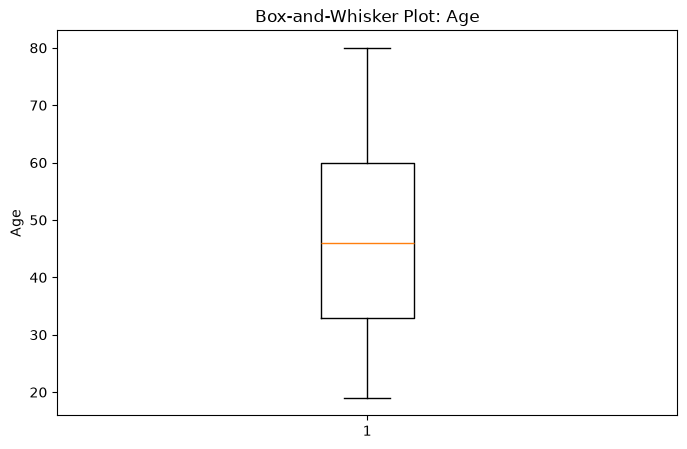

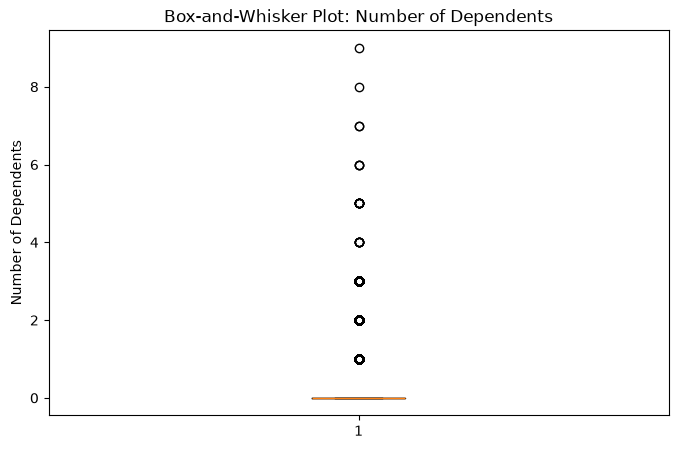

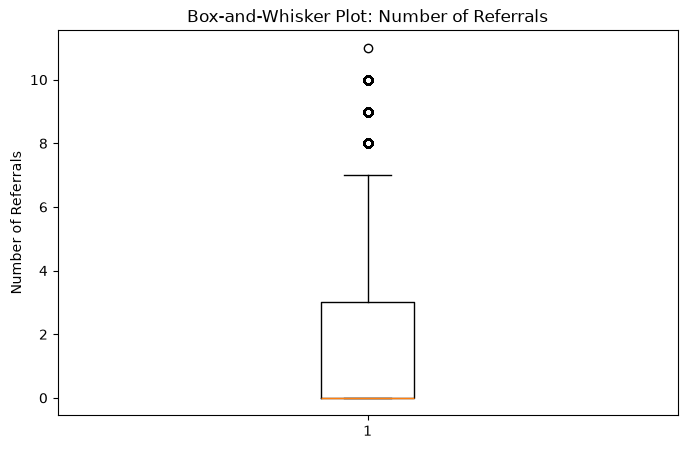

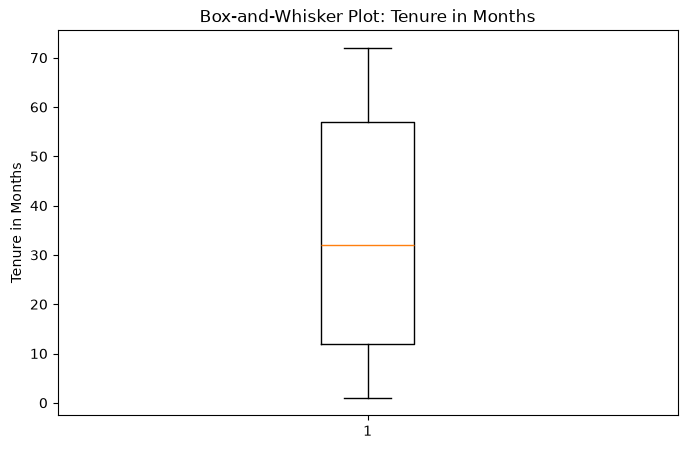

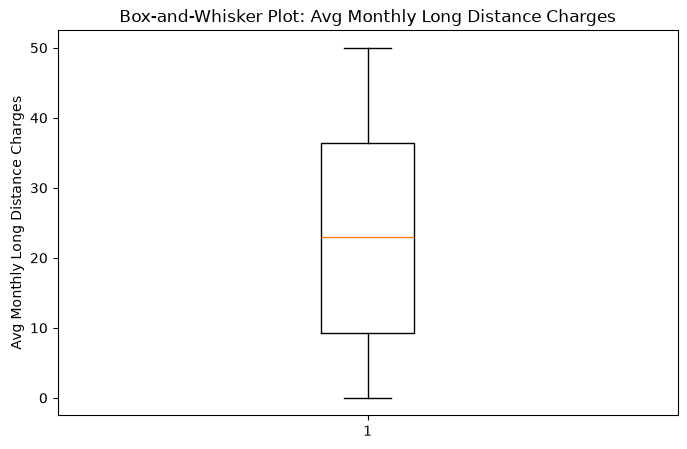

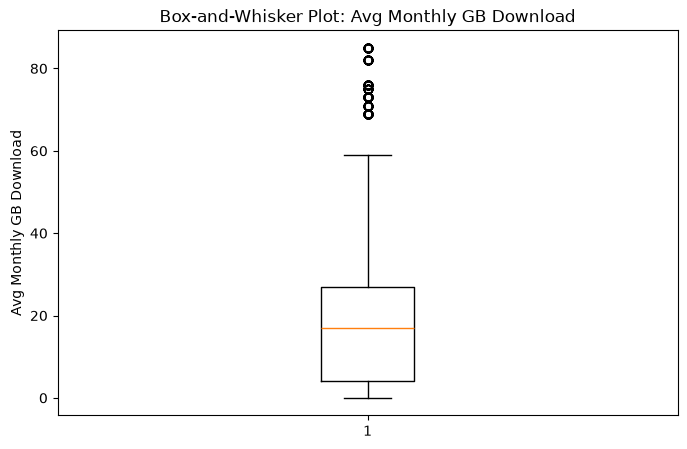

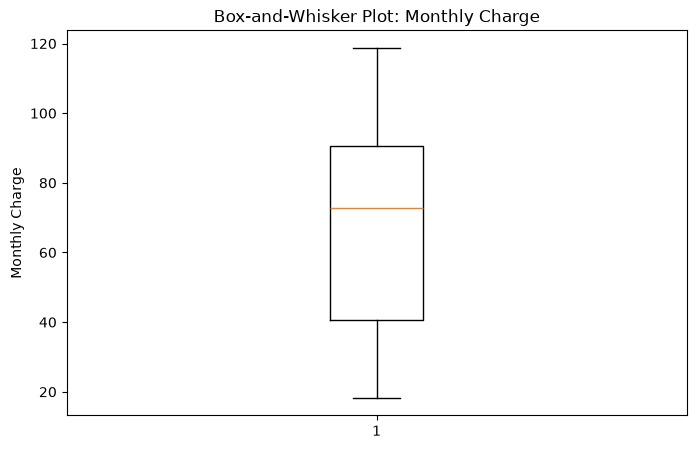

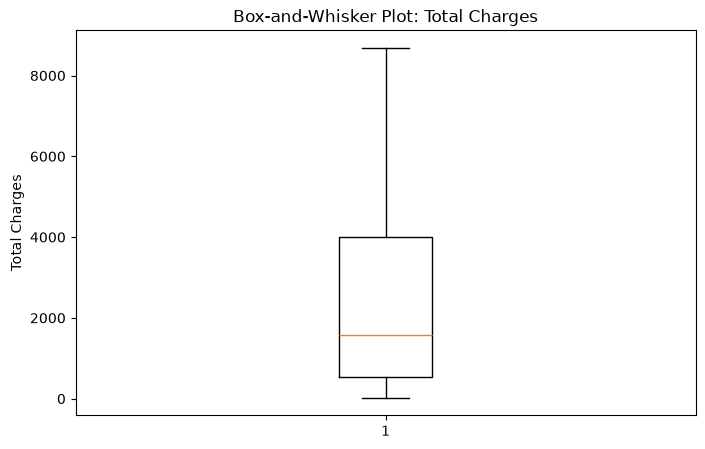

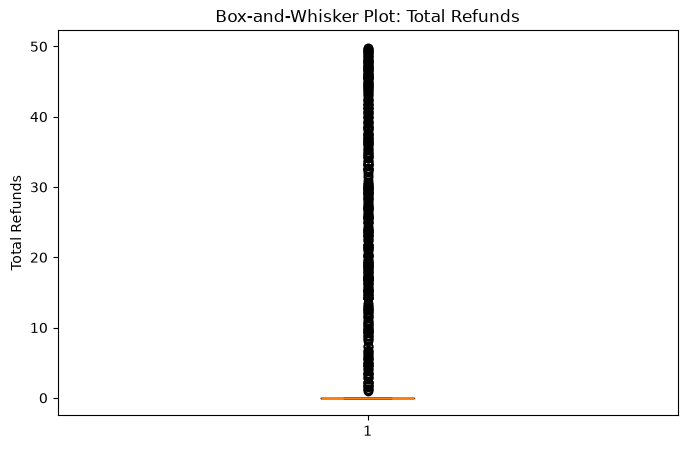

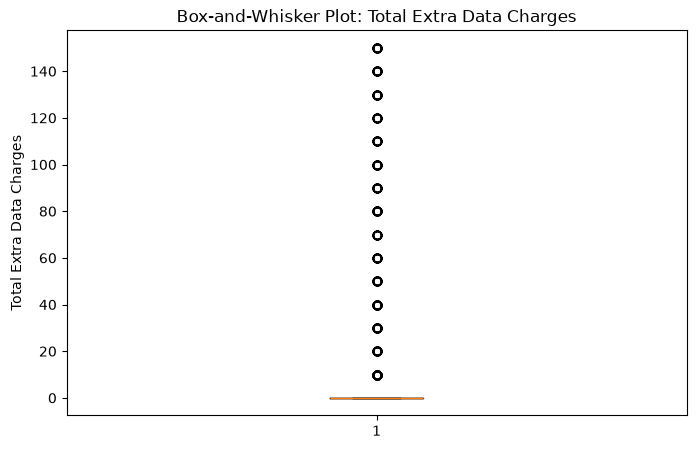

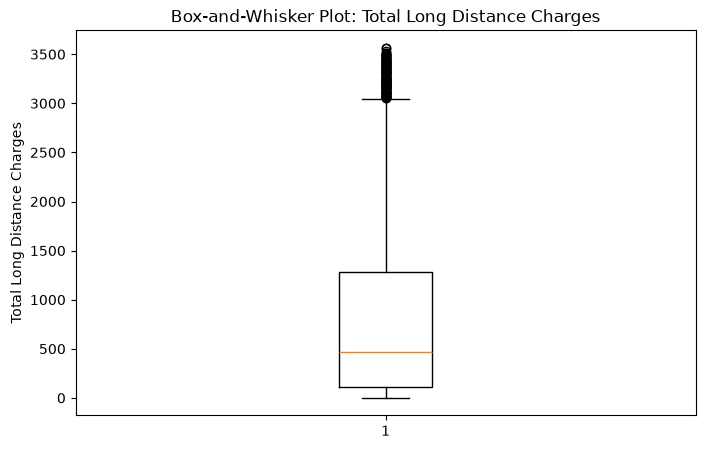

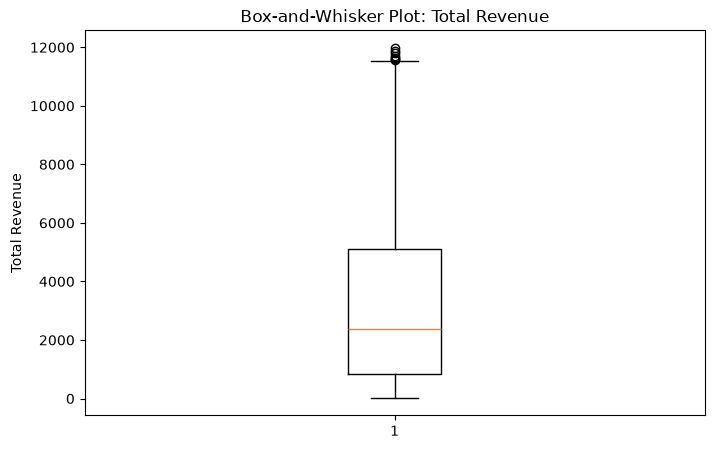

In [ ]:
numerical_cols = [
    "Age",
    "Number of Dependents",
    "Number of Referrals",
    "Tenure in Months",
    "Avg Monthly Long Distance Charges",
    "Avg Monthly GB Download",
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue"
]

for col in numerical_cols:
    plt.figure(figsize=(8, 5))

    plt.boxplot(df[col].dropna())

    plt.title(f"Box-and-Whisker Plot: {col}")
    plt.ylabel(col)

    plt.show()

# Generating box and whiskers to mathematically find statistical outliers for continuous numerical features.
# Some of these have strangely no box, they're all outliers.
# Will investigate, but some of them look very good, not alarming

In [41]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n----- {col} -----")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")


    # Now we see just what IS exactly considered a statistical outlier (by mathematical definitions, not thresholds set arbitrarily by me)
    # Number of Dependents is odd, all ranges are 0 thus causing all 1521 points to be outliers
    # Total Refunds too for 506 points
    # And Total Extra Data Charges too for 673 points
    # I'm reasoning that MOST customers have 0 for these values, causing the feature to be concentrated at 0, causing the outlier threshold to be extremely low and thus anyone not at 0 is an outlier
    # Thus, I will ignore these three feature's outliers for now, reasoning that they're just the way it's calculated and aren't abnormal or concerning.
    


----- Age -----
Q1: 33.0
Q3: 60.0
IQR: 27.0
Lower bound: -7.5
Upper bound: 100.5
Number of outliers: 0

----- Number of Dependents -----
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower bound: 0.0
Upper bound: 0.0
Number of outliers: 1521

----- Number of Referrals -----
Q1: 0.0
Q3: 3.0
IQR: 3.0
Lower bound: -4.5
Upper bound: 7.5
Number of outliers: 635

----- Tenure in Months -----
Q1: 12.0
Q3: 57.0
IQR: 45.0
Lower bound: -55.5
Upper bound: 124.5
Number of outliers: 0

----- Avg Monthly Long Distance Charges -----
Q1: 9.225000000000001
Q3: 36.425
IQR: 27.199999999999996
Lower bound: -31.574999999999996
Upper bound: 77.225
Number of outliers: 0

----- Avg Monthly GB Download -----
Q1: 4.0
Q3: 27.0
IQR: 23.0
Lower bound: -30.5
Upper bound: 61.5
Number of outliers: 336

----- Monthly Charge -----
Q1: 40.575
Q3: 90.6
IQR: 50.02499999999999
Lower bound: -34.46249999999999
Upper bound: 165.6375
Number of outliers: 0

----- Total Charges -----
Q1: 548.3
Q3: 4011.6
IQR: 3463.3
Lower bound: -4646.650000000001


In [42]:
Q1 = df["Total Revenue"].quantile(0.25)
Q3 = df["Total Revenue"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

revenue_outliers = df[
    (df["Total Revenue"] < lower_bound) |
    (df["Total Revenue"] > upper_bound)
]

print(
    revenue_outliers[
        [
            "Total Revenue",
            "Total Charges",
            "Total Refunds",
            "Total Extra Data Charges",
            "Total Long Distance Charges",
            "Monthly Charge",
            "Tenure in Months",
            "Phone Service",
            "Internet Service",
            "Customer Status"
        ]
    ]
)

# These 7 really high Total Revenue outliers
# It seems they share a pattern of having been with the company for 72 months
# That's 6 years of patronship with both phone service and internet service
# Definitely not abnormal, expect high revenue when someone stays with you for 6 years (they're gone now though)

      Total Revenue  Total Charges  Total Refunds  Total Extra Data Charges  \
95         11979.34        8496.70           0.00                         0   
2686       11688.90        8308.90           5.44                         0   
2785       11596.99        8013.55           0.00                        90   
3879       11795.78        8443.70           0.00                       120   
5360       11634.53        8672.45           0.00                         0   
5879       11868.34        8425.30           0.00                         0   
6576       11564.37        8240.85           0.00                         0   

      Total Long Distance Charges  Monthly Charge  Tenure in Months  \
95                        3482.64          114.90                72   
2686                      3385.44          117.60                72   
2785                      3493.44          116.45                72   
3879                      3232.08          115.75                72   
5360        

In [ ]:
print("Number of Dependents distribution:")
print(df["Number of Dependents"].value_counts().sort_index())

print("\nSummary statistics:")
print(df["Number of Dependents"].describe())

# Yeah, having 0 dependents is massively the most common, leaving anything else as "odd"/an outlier

# I think I'm going to investigate those with 4 or more dependents, quite rare to see.
# The statistics backs it up, 4 or more is quite unusual.

Number of Dependents distribution:
Number of Dependents
0    4954
1     518
2     499
3     482
4       6
5       9
6       3
7       2
8       1
9       1
Name: count, dtype: int64

Summary statistics:
count    6475.000000
mean        0.475676
std         0.967411
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.000000
Name: Number of Dependents, dtype: float64


In [ ]:
print("Number of Referrals distribution:")
print(df["Number of Referrals"].value_counts().sort_index())

print("\nSummary statistics:")
print(df["Number of Referrals"].describe())

# Again, mostly 0s and 1s are common, anything else is an outlier

# There seems to be just one guy with 11 referrals, interesting.
# I will investigate that one guy

Number of Referrals distribution:
Number of Referrals
0     3386
1     1053
2      224
3      245
4      230
5      251
6      211
7      240
8      204
9      218
10     212
11       1
Name: count, dtype: int64

Summary statistics:
count    6475.000000
mean        2.020386
std         3.020610
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        11.000000
Name: Number of Referrals, dtype: float64


In [ ]:
print("Avg Monthly GB Download:")
print(df["Avg Monthly GB Download"].describe())

print("\nTotal Refunds:")
print(df["Total Refunds"].describe())

print("\nTotal Extra Data Charges:")
print(df["Total Extra Data Charges"].describe())

print("\nTotal Long Distance Charges:")
print(df["Total Long Distance Charges"].describe())


# These extreme values aren't abnormal.
# The data dictionary or context never provided an upper cap, 85GB a month on average isn't abnormal for all we know.
# Refunds, $49.79 normal, not $0.00 is an outlier, normal
# Anything who doesn't have $0.00 in extra data charges is an outlier, normal
# I'm going to investigate some of these down below

Avg Monthly GB Download:
count    6475.000000
mean       20.881236
std        20.410173
min         0.000000
25%         4.000000
50%        17.000000
75%        27.000000
max        85.000000
Name: Avg Monthly GB Download, dtype: float64

Total Refunds:
count    6475.000000
mean        2.058703
std         8.085483
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        49.790000
Name: Total Refunds, dtype: float64

Total Extra Data Charges:
count    6475.000000
mean        7.183012
std        25.824131
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       150.000000
Name: Total Extra Data Charges, dtype: float64

Total Long Distance Charges:
count    6475.000000
mean      799.286948
std       854.561590
min         0.000000
25%       107.040000
50%       471.750000
75%      1283.715000
max      3564.720000
Name: Total Long Distance Charges, dtype: float64


In [ ]:
dependent_outliers = df[df["Number of Dependents"] >= 4]

print(dependent_outliers[
    [
        "Number of Dependents",
        "Age",
        "Married",
        "Tenure in Months",
        "Customer Status"
    ]
])

# Most of these seem 'normal', middle aged guys married with many dependents with a long tenure.
# There seems to be this one guy with 9 dependents at 23 years old, married and 21 months in tenure.
# It's really unusual, but nothing impossible. These seem okay to me

      Number of Dependents  Age  Married  Tenure in Months  Customer Status
172                      4   33        1                66                0
177                      6   54        1                27                0
480                      6   56        1                49                0
1175                     5   52        0                10                0
1443                     4   49        1                40                0
2228                     5   49        0                14                0
2503                     4   44        1                72                0
2666                     9   23        1                21                0
2724                     4   32        0                 7                1
2943                     5   35        1                59                0
3023                     6   61        1                 7                1
3040                     5   37        1                27                0
3103        

In [ ]:
print(df[df["Number of Referrals"] == 11])


# This one guy with 11 referrals is seemingly just a normal dude
# 46 years old, middle aged guy, probably has a bunch of friends to referral to
# Married too, big network, one of the longest tenures at the company so he's stayed a while (implying he's happy with or at least not unhappy about the company's services)
# Minorly odd he doesn't have the telephone service, and despite having internet service he on average only downloads 17GB per month, though not abnormal.
# Yeah, it's okay

      Gender  Age  Married  Number of Dependents  Number of Referrals  \
6541       1   46        1                     0                   11   

      Tenure in Months  Phone Service  Avg Monthly Long Distance Charges  \
6541                72              0                                0.0   

      Internet Service  Avg Monthly GB Download  Online Security  \
6541                 1                     17.0              1.0   

      Online Backup  Device Protection Plan  Premium Tech Support  \
6541            1.0                     1.0                   1.0   

      Streaming TV  Streaming Movies  Streaming Music  Unlimited Data  \
6541           0.0               0.0              0.0             1.0   

      Monthly Charge  Total Charges  Total Refunds  Total Extra Data Charges  \
6541           45.25         3139.8            0.0                         0   

      Total Long Distance Charges  Total Revenue  Customer Status  \
6541                          0.0         3139.

In [ ]:
print(
    df["Avg Monthly GB Download"]
    .value_counts()
    .sort_index()
)

# There's 45 different people using 85GB a month on average, seems okay, not just one crazy dude
# A minority for sure, but not abnormal

Avg Monthly GB Download
0.0     1320
2.0      108
3.0      125
4.0      119
5.0      104
6.0      106
7.0      108
8.0      115
9.0      107
10.0     123
11.0     133
12.0     131
13.0     152
14.0     113
15.0     124
16.0     149
17.0     144
18.0     159
19.0     211
20.0     142
21.0     157
22.0     160
23.0     169
24.0     137
25.0     117
26.0     174
27.0     187
28.0     139
29.0     129
30.0     184
39.0       1
41.0      63
42.0      44
46.0      18
47.0      35
48.0      79
51.0      86
52.0     114
53.0      81
56.0      14
57.0      34
58.0      44
59.0     180
69.0      70
71.0      39
73.0      77
75.0      14
76.0      53
82.0      38
85.0      45
Name: count, dtype: int64


In [ ]:
gb_outliers = df[df["Avg Monthly GB Download"] > 61.5]

print(gb_outliers["Avg Monthly GB Download"].describe())


# And yeah, strong evidence that a high usage is nothing abnormal, average is 75.12GB per month

count    336.000000
mean      75.116071
std        5.425884
min       69.000000
25%       71.000000
50%       73.000000
75%       76.000000
max       85.000000
Name: Avg Monthly GB Download, dtype: float64


In [ ]:
long_distance_outliers = df[df["Total Long Distance Charges"] > 3048.7275]

print(long_distance_outliers[
    [
        "Total Long Distance Charges",
        "Avg Monthly Long Distance Charges",
        "Tenure in Months",
        "Monthly Charge",
        "Phone Service",
        "Customer Status"
    ]
])

# It seems there are 129 people with the highest total long distance charge.
# Notice commonly it's found in customers with a high monthly charge as well as a long tenure, this explains it
# Not unusual, should keep the data.

      Total Long Distance Charges  Avg Monthly Long Distance Charges  \
81                        3219.48                              48.78   
95                        3482.64                              48.37   
154                       3142.30                              46.90   
269                       3169.77                              47.31   
322                       3427.20                              47.60   
...                           ...                                ...   
6753                      3152.64                              49.26   
6932                      3225.42                              48.87   
6994                      3129.84                              43.47   
7018                      3306.96                              45.93   
7028                      3266.25                              48.75   

      Tenure in Months  Monthly Charge  Phone Service  Customer Status  
81                  66           89.40              1         